We are experimenting to see whether we can infer significant information about the signatures from noisy samples (ie samples containing two cell types in known proportions but such that you do not know which reads belong to which cell type).

In [176]:
import numpy as np
from scipy import optimize
import cvxpy as cp
import matplotlib.pyplot as plt

## Experiment 1: no pooling of counts between signatures

We need to model the following things:
- at least three samples
- two cell types (0: healthy and 1: tumor)
- a single region
- at least three signatures (reads)

In [363]:
N_SAMPLES = 3
N_CTYPES = 2
N_SIGNATURES = 3
samples_ctype_proportions = np.array([
    [0.8, 0.2],
    [0.5, 0.5],
    [0.2, 0.8],
]) # (n_samples, n_ctypes)
samples_read_counts = np.array(
    [1000, 10, 10]
)
signatures = np.array([
    [0, 0, 0, 0],
    [0, 0, 1, 1],
    [1, 1, 1, 1]
])
signatures_prop_per_ctype = np.array([
    [0.0, 0.0, 1.0],
    [0.5, 0.5, 0.0]
]) # (n_ctypes, n_signatures)

In [364]:
# sample the signatures contents for each sample
ctype_counts_per_sample = [
    np.random.multinomial(samples_read_counts[i], samples_ctype_proportions[i]) for i in range(N_SAMPLES)
]
ctype_counts_per_sample = np.array(ctype_counts_per_sample)
ctype_counts_per_sample # (n_samples, n_ctypes)

signature_counts_per_sample = (ctype_counts_per_sample @ signatures_prop_per_ctype).astype(int)
signature_counts_per_sample # (n_samples, n_signatures)

signature_proportions_per_sample = signature_counts_per_sample / signature_counts_per_sample.sum(axis=1, keepdims=True)

In [374]:
# naive soft label construction
# for each signature, we compute a weighted average of the sample ctype proportions
pseudo_global_counts_per_ctype = signature_counts_per_sample.sum(axis=0) @ samples_ctype_proportions
naive_soft_labels = np.zeros((N_SIGNATURES, N_CTYPES))
for i in range(N_SIGNATURES):
    pseudo_counts = np.zeros(N_CTYPES)
    for j in range(N_SAMPLES):
        pseudo_counts += signature_counts_per_sample[j, i] * samples_ctype_proportions[j]
    normalized_pseudo_counts = pseudo_counts / pseudo_global_counts_per_ctype
    naive_soft_labels[i] = normalized_pseudo_counts / normalized_pseudo_counts.sum()
naive_soft_labels.round(2)

array([[0.89, 0.11],
       [0.89, 0.11],
       [0.9 , 0.1 ]])

In [372]:
pseudo_global_counts_per_ctype

array([303.7, 715.3])

In [366]:
# soft label construction using equal weights for each sample
naive_soft_labels_equal_weights = np.zeros((N_SIGNATURES, N_CTYPES))
for i in range(N_SIGNATURES):
    for j in range(N_SAMPLES):
        naive_soft_labels_equal_weights[i] += signature_proportions_per_sample[j, i] * samples_ctype_proportions[j]
    naive_soft_labels_equal_weights[i] /= N_SAMPLES
naive_soft_labels_equal_weights.round(2).T

array([[0.12, 0.12, 0.26],
       [0.18, 0.18, 0.14]])

In [367]:
# least squares
F = cp.Variable((N_CTYPES, N_SIGNATURES), nonneg=True)
objective = cp.Minimize(cp.sum_squares(samples_ctype_proportions @ F - signature_proportions_per_sample))
constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
problem = cp.Problem(objective, constraints)
problem.solve()
F_solution = F.value
F_solution.round(2)

array([[0.08, 0.08, 0.83],
       [0.5 , 0.5 , 0.  ]])

The least square imputation of ctypes per signature is highly dependent on the number of samples.

In [368]:
def compute_mse_per_sample_size(sample_size = 1000):
    # sample the signatures contents for each sample
    ctype_counts_per_sample = np.array([
        np.random.multinomial(sample_size, samples_ctype_proportions[i]) for i in range(N_SAMPLES)
    ])
    signature_counts_per_sample = (ctype_counts_per_sample @ signatures_prop_per_ctype).astype(int)
    signature_proportions_per_sample = signature_counts_per_sample / signature_counts_per_sample.sum(axis=1, keepdims=True)

    # least squares
    F = cp.Variable((N_CTYPES, N_SIGNATURES), nonneg=True)
    objective = cp.Minimize(cp.sum_squares(samples_ctype_proportions @ F - signature_proportions_per_sample))
    constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
    problem = cp.Problem(objective, constraints)
    problem.solve()
    F_solution = F.value

    mse = np.mean((F_solution - signatures_prop_per_ctype) ** 2)
    return mse

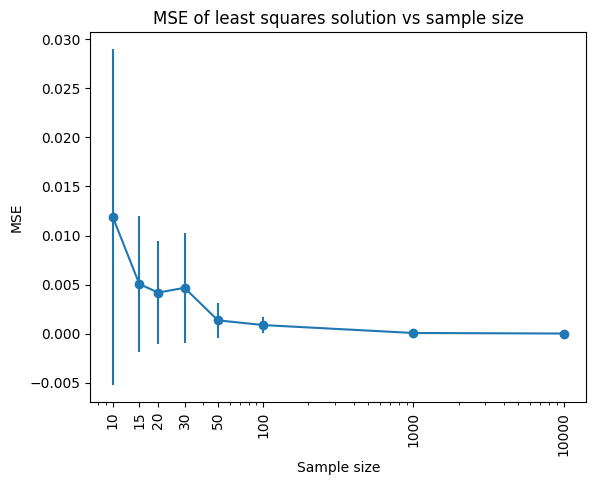

In [362]:
# plot mse per sample size
sample_sizes = [10, 15, 20, 30, 50, 100, 1000, 10000]
mse_means = []
mse_stds = []
for sample_size in sample_sizes:
    tmp_mse = []
    for _ in range(20):
        tmp_mse.append(compute_mse_per_sample_size(sample_size))
    mse_means.append(np.mean(tmp_mse))
    mse_stds.append(np.std(tmp_mse))

plt.errorbar(sample_sizes, mse_means, yerr=mse_stds, fmt='-o')
plt.xscale('log')
plt.xlabel('Sample size')
plt.ylabel('MSE')
plt.xticks(sample_sizes, labels=sample_sizes, rotation=90)
plt.title('MSE of least squares solution vs sample size')
plt.show()